## Task 1: Delivery Time Statistical Profiler

In [5]:
import statistics

delivery_times = [24, 27, 29, 25, 31, 28, 26, 30, 27, 33, 22, 35, 29, 38, 26, 28, 24, 92, 105, 87]

mean_value = statistics.mean(delivery_times)
median_value = statistics.median(delivery_times)
mode_value = statistics.mode(delivery_times)
variance_value = statistics.variance(delivery_times)
std_value = statistics.stdev(delivery_times)

if mean_value > median_value:
    skew_direction = "Right-skewed"
elif mean_value < median_value:
    skew_direction = "Left-skewed"
else:
    skew_direction = "Approximately symmetrical"

print("=" * 45)
print("DELIVERY TIME STATISTICAL REPORT")
print("=" * 45)
print(f"{'Mean':<25}: {mean_value:.2f} minutes")
print(f"{'Median':<25}: {median_value:.2f} minutes")
print(f"{'Mode':<25}: {mode_value:.2f} minutes")
print(f"{'Variance':<25}: {variance_value:.2f}")
print(f"{'Standard Deviation':<25}: {std_value:.2f} minutes")
print(f"{'Skewness Direction':<25}: {skew_direction}")
print("-" * 45)
print("Conclusion: The distribution is right-skewed because")
print("the mean is greater than the median.")
print("=" * 45)

DELIVERY TIME STATISTICAL REPORT
Mean                     : 38.30 minutes
Median                   : 28.50 minutes
Mode                     : 24.00 minutes
Variance                 : 613.69
Standard Deviation       : 24.77 minutes
Skewness Direction       : Right-skewed
---------------------------------------------
Conclusion: The distribution is right-skewed because
the mean is greater than the median.


## Task 2: Order Dataset Preprocessor

In [6]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

orders = pd.DataFrame({
    "order_id": range(1001, 1013),
    "restaurant_rating": [4.5, 4.1, None, 3.8, 4.7, None, 4.2, 3.9, 4.8, 4.0, 4.4, 3.7],
    "payment_method": ["Cash", "Card", "Wallet", "Card", "Cash", "Wallet", "Card", "Cash", "Wallet", "Card", "Cash", "Wallet"],
    "cuisine_type": ["Indian", "Chinese", "Italian", "Fast Food", "Indian", "Chinese", "Italian", "Fast Food", "Indian", "Chinese", "Italian", "Fast Food"],
    "order_value": [320.0, 540.0, 275.0, 180.0, 620.0, 410.0, 355.0, 225.0, 710.0, 465.0, 390.0, 205.0]
})

orders["restaurant_rating"] = orders["restaurant_rating"].fillna(
    orders["restaurant_rating"].mean()
)

print("Missing values after filling:")
print(orders.isnull().sum())

preprocessed = pd.get_dummies(
    orders,
    columns=["payment_method", "cuisine_type"],
    dtype=int
)

scaler = MinMaxScaler()
preprocessed[["restaurant_rating", "order_value"]] = scaler.fit_transform(
    preprocessed[["restaurant_rating", "order_value"]]
)

print("\nFinal Preprocessed DataFrame:")
print(preprocessed.to_string(index=False))

Missing values after filling:
order_id             0
restaurant_rating    0
payment_method       0
cuisine_type         0
order_value          0
dtype: int64

Final Preprocessed DataFrame:
 order_id  restaurant_rating  order_value  payment_method_Card  payment_method_Cash  payment_method_Wallet  cuisine_type_Chinese  cuisine_type_Fast Food  cuisine_type_Indian  cuisine_type_Italian
     1001           0.727273     0.264151                    0                    1                      0                     0                       0                    1                     0
     1002           0.363636     0.679245                    1                    0                      0                     1                       0                    0                     0
     1003           0.463636     0.179245                    0                    0                      1                     0                       0                    0                     1
     1004           0.09090

## Task 3: Order Cancellation Classifier with Evaluation

In [7]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

rng = np.random.default_rng(42)
n = 160

classifier_data = pd.DataFrame({
    "order_value": rng.uniform(100, 1000, n).round(2),
    "delivery_distance_km": rng.uniform(1, 20, n).round(2),
    "hour_of_day": rng.integers(0, 24, n),
    "restaurant_rating": rng.uniform(2.5, 5.0, n).round(2)
})

risk_score = (
    0.04 * classifier_data["delivery_distance_km"]
    + 0.45 * classifier_data["hour_of_day"].between(20, 23).astype(int)
    + 0.35 * (classifier_data["restaurant_rating"] < 3.5).astype(int)
    + 0.20 * (classifier_data["order_value"] < 250).astype(int)
)

classifier_data["cancelled"] = (
    risk_score.rank(method="first", ascending=False) <= 36
).astype(int)

X = classifier_data.drop(columns="cancelled")
y = classifier_data["cancelled"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=200
)

rf_model.fit(X_train, y_train)
predictions = rf_model.predict(X_test)

print("CLASSIFICATION REPORT")
print(classification_report(y_test, predictions, digits=3))

cm = confusion_matrix(y_test, predictions)
tn, fp, fn, tp = cm.ravel()

print("CONFUSION MATRIX")
print(pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
))

print(f"\nTN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0      0.957     0.880     0.917        25
           1      0.667     0.857     0.750         7

    accuracy                          0.875        32
   macro avg      0.812     0.869     0.833        32
weighted avg      0.893     0.875     0.880        32

CONFUSION MATRIX
          Predicted 0  Predicted 1
Actual 0           22            3
Actual 1            1            6

TN: 22
FP: 3
FN: 1
TP: 6


## Task 4: Customer Segmentation with K-Means and PCA Visualisation

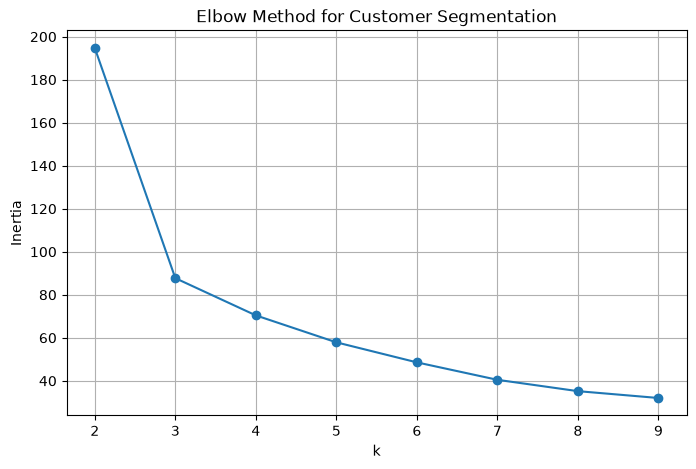

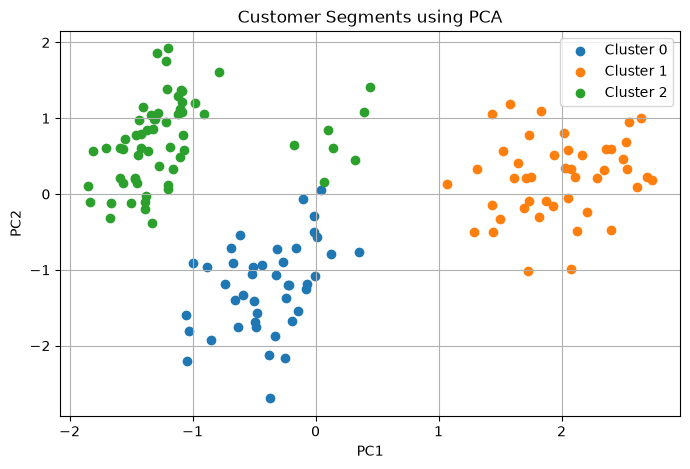

Cluster Counts:
cluster
0    43
1    45
2    62
Name: count, dtype: int64

Cluster Centroids:
           monthly_orders  avg_order_value  avg_delivery_rating
Cluster 0            9.70           501.78                 3.88
Cluster 1           18.42           810.40                 4.59
Cluster 2            4.84           279.89                 4.47


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

rng = np.random.default_rng(42)

segment_a = pd.DataFrame({
    "monthly_orders": rng.integers(2, 7, 55),
    "avg_order_value": rng.normal(250, 35, 55).clip(100, 400),
    "avg_delivery_rating": rng.normal(4.5, 0.25, 55).clip(1, 5)
})

segment_b = pd.DataFrame({
    "monthly_orders": rng.integers(7, 14, 50),
    "avg_order_value": rng.normal(500, 55, 50).clip(200, 800),
    "avg_delivery_rating": rng.normal(4.0, 0.30, 50).clip(1, 5)
})

segment_c = pd.DataFrame({
    "monthly_orders": rng.integers(14, 24, 45),
    "avg_order_value": rng.normal(800, 70, 45).clip(300, 1200),
    "avg_delivery_rating": rng.normal(4.6, 0.20, 45).clip(1, 5)
})

customers = pd.concat(
    [segment_a, segment_b, segment_c],
    ignore_index=True
)

features = [
    "monthly_orders",
    "avg_order_value",
    "avg_delivery_rating"
]

scaler = StandardScaler()
scaled_customers = scaler.fit_transform(customers[features])

inertias = []
k_values = range(2, 10)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(scaled_customers)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method for Customer Segmentation")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

optimal_k = 3

final_kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

customers["cluster"] = final_kmeans.fit_predict(scaled_customers)

pca = PCA(n_components=2)
pca_coordinates = pca.fit_transform(scaled_customers)

plt.figure(figsize=(8, 5))

for cluster_id in sorted(customers["cluster"].unique()):
    mask = customers["cluster"] == cluster_id
    plt.scatter(
        pca_coordinates[mask, 0],
        pca_coordinates[mask, 1],
        label=f"Cluster {cluster_id}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments using PCA")
plt.legend()
plt.grid(True)
plt.show()

print("Cluster Counts:")
print(customers["cluster"].value_counts().sort_index())

centroids = pd.DataFrame(
    scaler.inverse_transform(final_kmeans.cluster_centers_),
    columns=features,
    index=[f"Cluster {i}" for i in range(optimal_k)]
).round(2)

print("\nCluster Centroids:")
print(centroids)